In [1]:
!pip install tensorflow numpy matplotlib scikit-learn seaborn


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns


In [3]:
def generate_synthetic_data(n_samples=5000, n_features=20):
    t = np.arange(n_samples)

    # Base trend
    trend = 0.001 * t

    # Multi-seasonal components
    seasonal_1 = 0.5 * np.sin(2 * np.pi * t / 24)
    seasonal_2 = 0.2 * np.sin(2 * np.pi * t / 60)
    seasonal_3 = 0.1 * np.sin(2 * np.pi * t / 120)

    # Combine into base signal
    base_signal = trend + seasonal_1 + seasonal_2 + seasonal_3

    # Multivariate generation
    X = np.zeros((n_samples, n_features))
    for i in range(n_features):
        noise = np.random.normal(0, 0.05, n_samples)
        X[:, i] = base_signal * (1 + np.random.uniform(-0.3, 0.3)) + noise

    return X

data = generate_synthetic_data()
data.shape


(5000, 20)

In [4]:
LOOKBACK = 60       # Past 60 timesteps
FORECAST_STEPS = 10  # Predict next 10 timesteps

def create_sequences(data, lookback, horizon):
    X, Y = [], []
    for i in range(len(data) - lookback - horizon):
        X.append(data[i:i+lookback])
        Y.append(data[i+lookback:i+lookback+horizon])
    return np.array(X), np.array(Y)

X, Y = create_sequences(data, LOOKBACK, FORECAST_STEPS)
X.shape, Y.shape


((4930, 60, 20), (4930, 10, 20))

In [5]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

X_train.shape, X_test.shape


((3944, 60, 20), (986, 60, 20))

In [6]:
class PositionalEncoding(layers.Layer):
    def __init__(self, sequence_len, d_model):
        super().__init__()
        self.pos_encoding = self.get_positional_encoding(sequence_len, d_model)

    def get_positional_encoding(self, seq_len, d_model):
        angles = np.arange(seq_len)[:, np.newaxis] / np.power(
            10000,
            (2 * (np.arange(d_model)[np.newaxis, :] // 2)) / np.float32(d_model)
        )

        angles[:, 0::2] = np.sin(angles[:, 0::2])
        angles[:, 1::2] = np.cos(angles[:, 1::2])
        return tf.cast(angles, dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pos_encoding


In [7]:
def build_transformer(input_shape, forecast_steps):
    inputs = layers.Input(shape=input_shape)

    # Positional encoding
    x = PositionalEncoding(LOOKBACK, input_shape[-1])(inputs)

    # Transformer block
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    attn = layers.LayerNormalization()(attn + x)

    ffn = layers.Dense(128, activation="relu")(attn)
    ffn = layers.Dense(input_shape[-1])(ffn)
    x_out = layers.LayerNormalization()(attn + ffn)

    # Flatten + Dense for multi-step output
    x_flat = layers.Flatten()(x_out)
    outputs = layers.Dense(forecast_steps * input_shape[-1])(x_flat)
    outputs = layers.Reshape((forecast_steps, input_shape[-1]))(outputs)

    model = Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mse")
    return model

transformer_model = build_transformer((LOOKBACK, data.shape[1]), FORECAST_STEPS)
transformer_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60, 20)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 60, 20)    │          0 │ input_layer[0][0] │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 20)    │     10,644 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 60, 20)    │          0 │ multi_head_atten… │
│                     │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 60, 20)    │         40 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 60, 128)   │      2,688 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 60, 20)    │      2,580 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 60, 20)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 20)    │         40 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1200)      │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 200)       │    240,200 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 10, 20)    │          0 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 256,192 (1000.75 KB)

 Trainable params: 256,192 (1000.75 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = transformer_model.fit(
    X_train, Y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32
)


Epoch 1/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 0.8652 - val_loss: 0.0649
Epoch 2/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0364 - val_loss: 0.0964
Epoch 3/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0225 - val_loss: 0.0726
Epoch 4/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0179 - val_loss: 0.1108
Epoch 5/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0200 - val_loss: 0.0884
Epoch 6/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0147 - val_loss: 0.0182
Epoch 7/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0159 - val_loss: 0.0418
Epoch 8/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0140 - val_loss: 0.0490
Epoch 9/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0139 - val_loss: 0.0503
Epoch 10/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0115 - val_loss: 0.0407
Epoch 11/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0091 - val_loss: 0.0360
Epoch 12/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0083 - val_

In [9]:
def build_lstm(input_shape, forecast_steps):
    model = tf.keras.Sequential([
        layers.LSTM(64, return_sequences=False, input_shape=input_shape),
        layers.Dense(forecast_steps * input_shape[-1]),
        layers.Reshape((forecast_steps, input_shape[-1]))
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

lstm_model = build_lstm((LOOKBACK, data.shape[1]), FORECAST_STEPS)
lstm_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 200)            │        13,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 10, 20)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,760 (135.78 KB)

 Trainable params: 34,760 (135.78 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_lstm = lstm_model.fit(
    X_train, Y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32
)


Epoch 1/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.9115 - val_loss: 0.8424
Epoch 2/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1920 - val_loss: 0.5313
Epoch 3/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0763 - val_loss: 0.3514
Epoch 4/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0369 - val_loss: 0.2226
Epoch 5/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0289 - val_loss: 0.1670
Epoch 6/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0223 - val_loss: 0.1415
Epoch 7/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0200 - val_loss: 0.1041
Epoch 8/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0176 - val_loss: 0.1145
Epoch 9/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0164 - val_loss: 0.1286
Epoch 10/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0159 - val_loss: 0.0772
Epoch 11/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0137 - val_loss: 0.0770
Epoch 12/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0128 - val_l

In [11]:
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
    mae = mean_absolute_error(y_true.flatten(), y_pred.flatten())
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return rmse, mae, mape

pred_tf = transformer_model.predict(X_test)
pred_lstm = lstm_model.predict(X_test)

print("Transformer Performance:", evaluate(Y_test, pred_tf))
print("LSTM Performance:", evaluate(Y_test, pred_lstm))


31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Transformer Performance: (np.float64(0.31391891020444107), 0.2597993292450345, np.float64(5.687663557084922))
LSTM Performance: (np.float64(0.7262666804738781), 0.5815769226841018, np.float64(12.660924931817942))


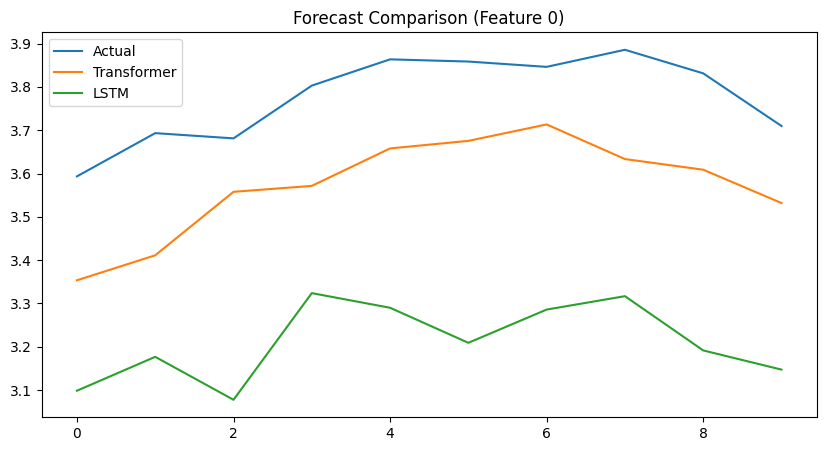

In [12]:
i = 100  # sample index

plt.figure(figsize=(10,5))
plt.plot(Y_test[i,:,0], label="Actual")
plt.plot(pred_tf[i,:,0], label="Transformer")
plt.plot(pred_lstm[i,:,0], label="LSTM")
plt.legend()
plt.title("Forecast Comparison (Feature 0)")
plt.show()


In [14]:
class AttentionWithWeights(layers.Layer):
    def __init__(self, num_heads, key_dim):
        super().__init__()
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)

    def call(self, inputs):
        attn_output, attn_scores = self.mha(
            inputs, inputs, return_attention_scores=True
        )
        self.last_scores = attn_scores   # Save for visualization
        return attn_output


In [15]:
def build_transformer_with_attention(input_shape, forecast_steps):
    inputs = layers.Input(shape=input_shape)

    x = PositionalEncoding(LOOKBACK, input_shape[-1])(inputs)

    # custom attention that stores weights
    attn_layer = AttentionWithWeights(num_heads=4, key_dim=32)
    attn_output = attn_layer(x)

    x_norm = layers.LayerNormalization()(attn_output + x)

    ffn = layers.Dense(128, activation="relu")(x_norm)
    ffn = layers.Dense(input_shape[-1])(ffn)

    x_out = layers.LayerNormalization()(x_norm + ffn)

    flat = layers.Flatten()(x_out)
    out = layers.Dense(forecast_steps * input_shape[-1])(flat)
    out = layers.Reshape((forecast_steps, input_shape[-1]))(out)

    model = Model(inputs, out)
    model.attn_layer = attn_layer         # attach layer for access later
    model.compile(optimizer="adam", loss="mse")
    return model

transformer = build_transformer_with_attention((LOOKBACK, data.shape[1]), FORECAST_STEPS)
transformer.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 60, 20)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 60, 20)    │          0 │ input_layer_2[0]… │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_with_wei… │ (None, 60, 20)    │     10,644 │ positional_encod… │
│ (AttentionWithWeig… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 60, 20)    │          0 │ attention_with_w… │
│                     │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 20)    │         40 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 60, 128)   │      2,688 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 60, 20)    │      2,580 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 60, 20)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 20)    │         40 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 1200)      │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 200)       │    240,200 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 10, 20)    │          0 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 256,192 (1000.75 KB)

 Trainable params: 256,192 (1000.75 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = transformer.fit(
    X_train, Y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)


Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - loss: 0.8461 - val_loss: 0.0631
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0329 - val_loss: 0.0518
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0202 - val_loss: 0.0466
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0180 - val_loss: 0.0331
Epoch 5/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0169 - val_loss: 0.0442
Epoch 6/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0136 - val_loss: 0.0500
Epoch 7/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0126 - val_loss: 0.0548
Epoch 8/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0105 - val_loss: 0.0265
Epoch 9/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0125 - val_loss: 0.0411
Epoch 10/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0093 - val_loss: 0.0520
